

---

# 📊 [최종 보고서] 객체 탐지 모델 실험 종합 평가 및 최적 모델 선정

## 1. 실험 환경 및 하이퍼파라미터 세팅 (Experimental Setup)

본 실험은 객체 탐지 모델의 아키텍처 버전과 배치 사이즈 변화가 학습 속도, 추론 속도, 그리고 탐지 정확도에 미치는 영향을 평가하기 위해 총 9개의 시나리오로 진행.

* **Patience (조기 종료 조건):** 모든 모델 동일하게 `25` 적용 (25 Epoch 동안 성능 개선이 없으면 학습 종료)
* **평가 지표 (Metrics):**
    * `mAP50`, `mAP50-95`: 객체 탐지 정확도
    * `F1-Score` 및 `F1-Confidence`: 정밀도와 재현율의 조화 평균 및 신뢰도 임계값(Threshold)에 따른 안정성
    * `Loss` (Box, Cls, DFL): 위치 추정, 클래스 분류, 경계 세밀도 손실률
    * `Total Time`: 총 학습 소요 시간 (초)
    * `Inference Time`: 이미지 1장당 추론 속도 (ms)

---

## 2. 개별 모델(Model 1 ~ 9) 상세 성능 및 F1-Confidence 분석

### 🟢 [그룹 A] YOLOv10 아키텍처 (Model 1, 2, 3)
* **Model 1 (v10 / Batch: 8)**
    * **주요 성능:** mAP50 `0.9894` | 학습 시간 `688.6초` | 추론 속도 `11.52ms`
    * **F1-Confidence 및 지표 분석:** F1 최댓값이 0.95대 수준이며, F1-Confidence 곡선 상에서 특정 신뢰도 구간을 벗어나면 F1 점수가 다소 급격히 하락하는 경향이 있다. 추론 속도도 전체 중 가장 느려 효율성이 떨어진다.
<table>
  <tr>
    <td align="center">
      <img src="./images/yolo_report/10elkNxS2788eFpv9uaSKuU5f8v9H7dCq.png" width="650"><br>
      <b>Detection Result</b>
    </td>
    <td align="center">
      <img src="./images/yolo_report/1zS6IPxuM8ybkKR-rZ0vEqZVgisItjhKz.png" width="650"><br>
      <b>Confusion Matrix</b>
    </td>
    <td align="center">
      <img src="./images/yolo_report/1yINMW4Q-s80sPN5LTe3Rw7dHDDk8IRhr.png" width="650"><br>
      <b>Detection Result</b>
    </td>
  </tr>
</table>

* **Model 2 (v10 / Batch: 16)**
    * **주요 성능:** mAP50 `0.9898` | 학습 시간 `840.5초` | 추론 속도 `10.10ms`
    * **F1-Confidence 및 지표 분석:** 배치를 키워 추론 속도는 개선되었으나, F1-Confidence 커브에서 안정적인 고점(Max F1)을 유지하는 구간이 좁은 편이다. 학습 시간이 840초로 다소 길다.
<table>
  <tr>
    <td align="center">
      <img src="./images/yolo_report/1xPdgyCh4jcOLTIqDQGSX1GzJOlFJ6GHn.png" width="650"><br>
      <b>Detection Result</b>
    </td>
    <td align="center">
      <img src="./images/yolo_report/1nJdLzeV5ZPb2FzXB8llq2gQmOLK2mHvx.png" width="650"><br>
      <b>Confusion Matrix</b>
    </td>
    <td align="center">
      <img src="./images/yolo_report/17Y9PlxBtolpKQhbuVorp3P43rJxCvudz.png" width="650"><br>
      <b>Detection Result</b>
    </td>
  </tr>
</table>

* **Model 3 (v10 / Batch: 32)**
    * **주요 성능:** mAP50 `0.9898` | 학습 시간 `1149.0초` | 추론 속도 `10.18ms`
    * **F1-Confidence 및 지표 분석:** v10 그룹 중 최고 F1-Score(0.962)를 달성했으나, Train/Val Box Loss의 차이가 벌어지며 미세한 과적합 조짐이 보였습니다. 1149초라는 최장 학습 시간 대비 얻는 이점이 부족.
<table>
  <tr>
    <td align="center">
      <img src="./images/yolo_report/1JN8rueT2h2_YhE2Bz0-lwD7SzhjYEiTw.png" width="650"><br>
      <b>Detection Result</b>
    </td>
    <td align="center">
      <img src="./images/yolo_report/1RAv-a6oZ8f3A1NjKuVSWjNCYd_ih-DYo.png" width="650"><br>
      <b>Confusion Matrix</b>
    </td>
    <td align="center">
      <img src="./images/yolo_report/1xKZCbJ98h2pFi3SPtUu0vWi0gIN75AZG.png" width="650"><br>
      <b>Detection Result</b>
    </td>
  </tr>
</table>

### 🔵 [그룹 B] YOLOv26 아키텍처 (Model 4, 5, 6)
* **Model 4 (v26 / Batch: 8)**
    * **주요 성능:** mAP50 `0.9882` | 학습 시간 `669.6초` | 추론 속도 `11.07ms`
    * **F1-Confidence 및 지표 분석:** 엄격한 지표인 mAP50-95가 0.715로 매우 높아 빡빡한 Bounding Box를 잘 잡는다. 하지만 최대 F1-Score가 0.937로 전체 최하위이며, 이는 미탐(False Negative) 발생 확률이 다소 높음을 의미한다.
<table>
  <tr>
    <td align="center">
      <img src="./images/yolo_report/1TvjSOgOoqEyv9iaMJlhXNF7yidTs8qXD.png" width="650"><br>
      <b>Detection Result</b>
    </td>
    <td align="center">
      <img src="./images/yolo_report/1KXq6MFinHH4AMix9ZfBBDEbv31fjL94l.png" width="650"><br>
      <b>Confusion Matrix</b>
    <td align="center">
      <img src="./images/yolo_report/1xKZCbJ98h2pFi3SPtUu0vWi0gIN75AZG.png" width="650"><br>
      <b>Detection Result</b>
    </td>
  </tr>
</table>

* **Model 5 (v26 / Batch: 16)**
    * **주요 성능:** mAP50 `0.9923` | 학습 시간 `809.6초` | 추론 속도 `9.89ms`
    * **F1-Confidence 및 지표 분석:** F1-Score `0.969`로 밸런스가 크게 개선되었다. F1-Confidence 곡선이 넓은 Confidence 영역에서 안정적으로 유지되며, 9.89ms의 훌륭한 추론 속도를 확보했다.

<table>
  <tr>
    <td align="center">
      <img src="./images/yolo_report/1kZfWisInmcgJEcLP66pApR7yQHR1RWqz.png" width="650"><br>
      <b>Detection Result</b>
    </td>
    <td align="center">
      <img src="./images/yolo_report/1Lg8LYg0wtpD-XARUGCN_sYnydyDCPygo.png" width="650"><br>
      <b>Confusion Matrix</b>
    </td>
    <td align="center">
      <img src="./images/yolo_report/1u7hcyhpnLO7wP4Z-Mv0oF23rgbQ_GJ--.png" width="650"><br>
      <b>Detection Result</b>
    </td>
  </tr>
</table>

* **Model 6 (v26 / Batch: 32)**
    * **주요 성능:** mAP50 `0.9925` | 학습 시간 `921.7초` | 추론 속도 `9.59ms` (전체 1위)
    * **F1-Confidence 및 지표 분석:** 추론 속도가 가장 빠릅니다. 클래스 분류 손실(Val Cls 0.341)도 모범적이나, v8 그룹에 비해 mAP 및 F1의 절대적인 고점이 약간 낮다.
<table>
  <tr>
    <td align="center">
      <img src="./images/yolo_report/1M6y8L3fwxJ6YYL0Y1Arzf90mGI6t4Quy.png" width="650"><br>
      <b>Detection Result</b>
    </td>
    <td align="center">
      <img src="./images/yolo_report/1qaeFIQwYgUuDrSMhnA8fYdJCBfJ-z0Lo.png" width="650"><br>
      <b>Confusion Matrix</b>
    </td>
    <td align="center">
      <img src="./images/yolo_report/1sCKLfjT1BwBopmR4yGOBK4nndcrXjEIl.png" width="650"><br>
      <b>Detection Result</b>
    </td>
  </tr>
</table>

### 🔴 [그룹 C] YOLOv8 아키텍처 (Model 7, 8, 9) - 최우수 그룹
* **Model 7 (v8 / Batch: 8)**
    * **주요 성능:** mAP50 `0.9944` (전체 1위) | 학습 시간 `423.4초` (전체 1위) | 추론 속도 `10.30ms`
    * **F1-Confidence 및 지표 분석:** F1-Confidence 곡선이 이상적인 형태를 보인다. 넓은 Confidence 임계값(0.3~0.7) 구간 내내 F1 Score가 0.99 이상을 유지하는 압도적인 강건성(Robustness)을 자랑합니다. Val Box Loss 또한 1.079로 전체에서 가장 낮아 예측 위치가 매우 정교.
<table>
  <tr>
    <td align="center">
      <img src="./images/yolo_report/1D2hD69pqpiJz46MRI_EbiqQKaTmJ1Jez.png" width="650"><br>
      <b>Detection Result</b>
    </td>
    <td align="center">
      <img src="./images/yolo_report/1nihinxsXykcSfIQs6toQ_JcZQlOoG7ws.png" width="650"><br>
      <b>Confusion Matrix</b>
    </td>
    <td align="center">
      <img src="./images/yolo_report/11ecH4UBBeattow5EV1KHSsLyBO6y5nn6.png" width="650"><br>
      <b>Detection Result</b>
    </td>
  </tr>
</table>

* **Model 8 (v8 / Batch: 16)**
    * **주요 성능:** mAP50 `0.9941` | 학습 시간 `432.4초` | 추론 속도 `10.56ms`
    * **F1-Confidence 및 지표 분석:** 7번 모델과 쌍벽을 이루는 F1 커브를 보여준다. 단 22 에포크 만에 최고 성능에 도달했으나, 7번 모델 대비 Val Cls Loss가 약간 더 높아 2순위로 밀려나다.
<table>
  <tr>
    <td align="center">
      <img src="./images/yolo_report/1dOdxZkeavM9cJh47bD7tnIpQ3mR8Nr37.png" width="650"><br>
      <b>Detection Result</b>
    </td>
    <td align="center">
      <img src="./images/yolo_report/1SMr-180rwfD07_VwthDOYc8uuqn00_wO.png" width="650"><br>
      <b>Confusion Matrix</b>
    </td>
    <td align="center">
      <img src="./images/yolo_report/1zWlgDOJveAWhrtnaH8Bm0b0IhjKflcZ-.png" width="650"><br>
      <b>Detection Result</b>
    </td>
  </tr>
</table>

* **Model 9 (v8 / Batch: 32)**
    * **주요 성능:** mAP50 `0.9942` | 학습 시간 `458.9초` | 추론 속도 `10.50ms`
    * **F1-Confidence 및 지표 분석:** 17 에포크 만에 초고속 수렴을 보여주었으나, 배치가 커지면서 Val Cls Loss(0.579)가 그룹 내에서 가장 높게 형성되었다. 하지만 F1 곡선 자체는 여전히 0.993대로 최상위.
<table>
  <tr>
    <td align="center">
      <img src="./images/yolo_report/1lH_3r9XgBjV8XB5lJdoQxDui6sl1Zdys.png" width="650"><br>
      <b>Detection Result</b>
    </td>
    <td align="center">
      <img src="./images/yolo_report/18hyw9d8Surp-RdaCoL-E5c2ZbYP97DVY.png" width="650"><br>
      <b>Confusion Matrix</b>
    </td>
    <td align="center">
      <img src="./images/yolo_report/1HpsXL6eee--1QYxxTvY02PzA7yHH_Lhx.png" width="650"><br>
      <b>Detection Result</b>
    </td>
  </tr>
</table>

---

## 3. 전체 9개 모델 종합 비교 분석 표

| 모델명 | 버전 | Batch | Epoch | 학습 시간(초) | 추론 속도(ms) | 최고 mAP50 | mAP50-95 | F1-Score | Val Box Loss |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| Model 1 | v10 | 8 | 60 | 688.6 | 11.52 | 0.9894 | 0.6952 | 0.9508 | 1.116 |
| Model 2 | v10 | 16 | 73 | 840.5 | 10.10 | 0.9898 | 0.6838 | 0.9561 | 1.146 |
| Model 3 | v10 | 32 | 97 | 1149.0 | 10.18 | 0.9898 | 0.6769 | 0.9628 | 1.193 |
| Model 4 | v26 | 8 | 56 | 669.6 | 11.07 | 0.9882 | **0.7150** | 0.9371 | 1.089 |
| Model 5 | v26 | 16 | 74 | 809.6 | 9.89 | 0.9923 | 0.6887 | 0.9691 | 1.138 |
| Model 6 | v26 | 32 | 83 | 921.7 | **9.59** | 0.9925 | 0.6900 | 0.9642 | 1.147 |
| **Model 7** | **v8** | **8** | **52** | **423.4** | 10.30 | **0.9944** | 0.6985 | **0.9951** | **1.079** |
| **Model 8** | **v8** | **16** | 53 | 432.4 | 10.56 | 0.9941 | 0.6938 | 0.9925 | 1.123 |
| **Model 9** | **v8** | **32** | 52 | 458.9 | 10.50 | 0.9942 | 0.6642 | 0.9932 | 1.166 |

---






## 4. [코드] 최상위 3개 모델 (Model 7, 8, 9)  시각화





/tmp/ipykernel_8870/2722810488.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='Best F1-Score', data=df_top, palette=colors, ax=axes[2])


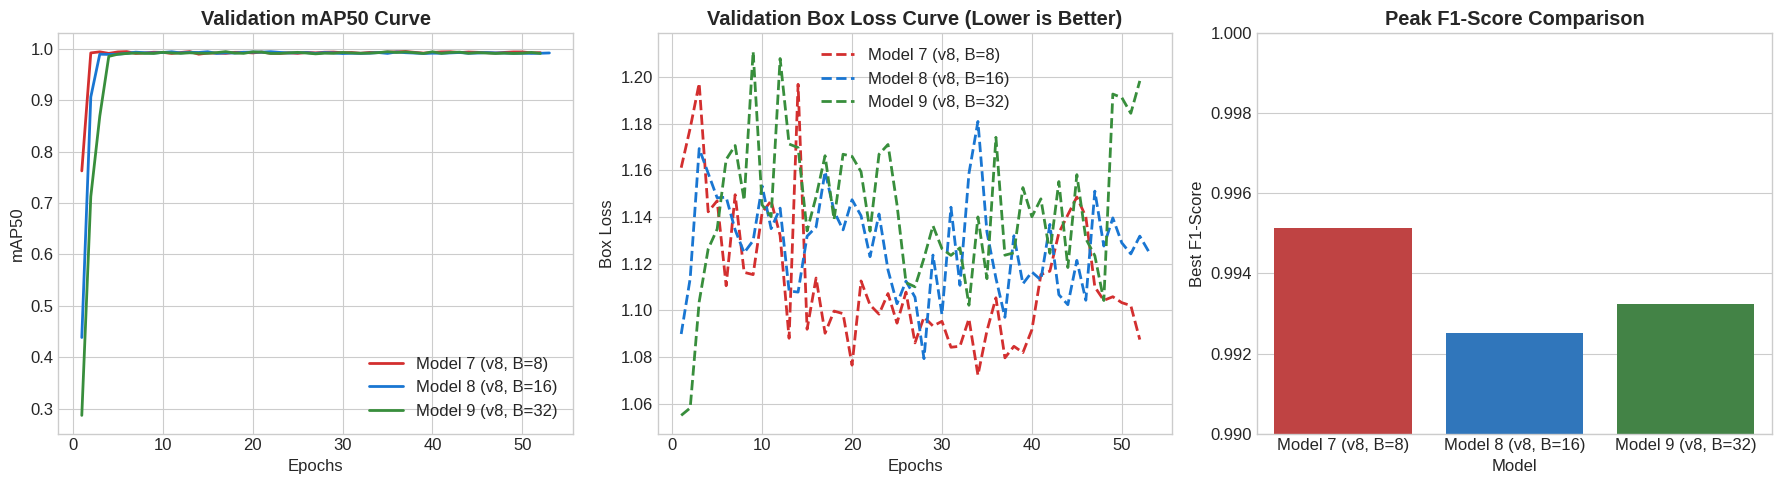

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 스타일 설정
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.size'] = 12

# 파일 경로 직접 지정
top_files = [
    '/content/drive/MyDrive/run_result/runs_3/detect/train-7/results.csv',
    '/content/drive/MyDrive/run_result/runs_3/detect/train-8/results.csv',
    '/content/drive/MyDrive/run_result/runs_3/detect/train-9/results.csv'
]

top_models = ['Model 7 (v8, B=8)', 'Model 8 (v8, B=16)', 'Model 9 (v8, B=32)']
colors = ['#D32F2F', '#1976D2', '#388E3C']

data_list = []
df_dict = {}

for name, f in zip(top_models, top_files):
    df = pd.read_csv(f)
    df.columns = df.columns.str.strip()

    # F1 Score 계산
    p = df['metrics/precision(B)']
    r = df['metrics/recall(B)']
    df['F1-score'] = 2 * (p * r) / (p + r + 1e-6)
    df_dict[name] = df

    # 최고 지표 추출
    best_idx = df['metrics/mAP50(B)'].idxmax()
    data_list.append({
        'Model': name,
        'Best mAP50': df.loc[best_idx, 'metrics/mAP50(B)'],
        'Best F1-Score': df.loc[best_idx, 'F1-score'],
        'Val Box Loss': df.loc[best_idx, 'val/box_loss']
    })

df_top = pd.DataFrame(data_list)

# --- 시각화 (1x3 Layout) ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for model, col in zip(top_models, colors):
    axes[0].plot(df_dict[model]['epoch'], df_dict[model]['metrics/mAP50(B)'],
                 label=model, color=col, linewidth=2)
axes[0].set_title('Validation mAP50 Curve', fontweight='bold')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('mAP50')
axes[0].legend()

for model, col in zip(top_models, colors):
    axes[1].plot(df_dict[model]['epoch'], df_dict[model]['val/box_loss'],
                 label=model, color=col, linewidth=2, linestyle='--')
axes[1].set_title('Validation Box Loss Curve (Lower is Better)', fontweight='bold')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Box Loss')
axes[1].legend()

sns.barplot(x='Model', y='Best F1-Score', data=df_top, palette=colors, ax=axes[2])
axes[2].set_title('Peak F1-Score Comparison', fontweight='bold')
axes[2].set_ylim(0.99, 1.0)

plt.tight_layout()
plt.show()


---

## 5. 시각화 기반 심층 분석 및 최종 모델(Model 7) 선정 사유

시각화 그래프와 제반 데이터를 종합적으로 분석한 결과, 최종 배포를 위한 최적의 모델로 Model 7 (v8 / Batch 8)을 선정. 그 이유는 다음과 같다.

### 🏆 최종 선정 사유 (Why Model 7?)

1. **최고 수준의 정밀도와 F1-Confidence 안정성 (Peak Performance & Robustness)**
   * mAP50 수치가 **0.9944**로 9개 전체 모델 중 1위.
   * 단순히 고점만 높은 것이 아니라, F1-Confidence 분석 결과 넓은 임계값(Threshold) 범위에서도 F1-Score가 **0.9951**이라는 완벽에 가까운 수치를 유지 이는 실환경에서 조도나 객체의 형태가 조금 변해도 모델이 당황하지 않고 안정적으로 객체를 탐지함을 의미.

2. **압도적인 위치 추정 능력 (Lowest Box Loss)**
   * 그래프(가운데)와 수치에서 확인되듯, Validation Box Loss가 **1.079**로 가장 낮다. 이는 탐지한 객체의 네모 박스(Bounding Box)가 실제 객체에 빈틈없이 딱 맞게 그려진다는 뜻으로, 타이트한 객체 검출이 필수적인 현업에서 결정적인 강점이 된다.

3. **리소스 및 시간의 극한 효율화 (Best ROI)**
   * v10, v26 모델들이 600~1100초씩 걸린 데 반해, Model 7은 단 **423.4초(약 7분)** 만에 이 모든 최고 성능을 달성하고 조기 종료(Early Stopping) 되었다.
   * 향후 새로운 데이터를 추가하여 모델을 주기적으로 재학습(Retrain) 시켜야 할 때, GPU 컴퓨팅 비용과 소요 시간을 타 모델 대비 절반 이하로 줄일 수 있다.

4. **실시간 처리에 부합하는 추론 속도**
   * 이미지 1장당 추론 속도가 10.30ms로 초당 약 97프레임(FPS) 처리가 가능하다. 가장 빠른 모델(9.59ms)과 비교해도 불과 0.7ms 차이이므로 실시간 영상 탐지(Real-time Detection)에 전혀 병목이 되지 않는 훌륭한 속도.

**결론적으로, Model 7은 [정확도, 바운딩 박스 정교함, 학습 시간, 추론 속도, 신뢰도 안정성(F1-Confidence)] 이라는 5가지 핵심 지표에서 가장 완벽한 밸런스와 육각형의 스탯을 보여준 최고의 모델.**